In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [2]:
model_df = pd.read_csv('/kaggle/input/datasets/micahluftig/bloomington-model-for-eval/bloomington_model_ready.csv')

In [3]:
feature_order = [
    "los_days", "age_at_first_visit",
    "spp_k9", "spp_other", "spp_wildlife",
    "akc_group_hound", "akc_group_mixed_breed", "akc_group_non_sporting",
    "akc_group_sporting", "akc_group_terrier", "akc_group_toy", "akc_group_working",
    "first_reason_medical", "first_reason_other", "first_reason_routine",
]

def build_features(df):
    x = pd.DataFrame(index=df.index)
    x['los_days'] = df['los_days']
    x['age_at_first_visit'] = df['age_in_years']
    spp = df['spp'].astype(str).str.lower()
    x['spp_k9'] = (spp == 'k9').astype(int)
    x['spp_wildlife'] = (spp == 'wildlife').astype(int)
    x['spp_other'] = ((~spp.isin(['k9', 'fel'])).astype(int) - x['spp_wildlife']).clip(lower=0)
    akc = df['akc_group'].astype(str).str.lower()
    for group in ['hound', 'mixed_breed', 'non_sporting', 'sporting', 'terrier', 'toy', 'working']:
        x[f'akc_group_{group}'] = (akc == group).astype(int)
    reason = df['intake_reason'].astype(str).str.lower()
    for r in ['medical', 'other', 'routine']:
        x[f'first_reason_{r}'] = (reason == r).astype(int)
    return x[feature_order]

bloomington_clean_features = model_df.dropna(subset=['los_days', 'age_in_years', 'spp', 'akc_group', 'intake_reason']).copy()
x_bloomington_full = build_features(bloomington_clean_features)
y_bloomington_full = bloomington_clean_features['was_returned'].astype(int)

print(x_bloomington_full.shape)
print(f"Recidivism rate: {y_bloomington_full.mean():.2%} ({y_bloomington_full.sum()} of {len(y_bloomington_full)})")

(7199, 15)
Recidivism rate: 3.94% (284 of 7199)


In [4]:
x_train, x_test, y_train, y_test = train_test_split(
    x_bloomington_full, y_bloomington_full, test_size=0.2, random_state=42, stratify=y_bloomington_full
)

bloomington_model = RandomForestClassifier(
    class_weight='balanced', n_estimators=300, max_depth=8, min_samples_leaf=20, random_state=42
)
bloomington_model.fit(x_train, y_train)

y_pred = bloomington_model.predict(x_test)
print(classification_report(y_test, y_pred, target_names=['No Return', 'Returned']))

bloomington_own_proba = bloomington_model.predict_proba(x_test)[:, 1]
print(f"ROC AUC (Bloomington model, own test set): {roc_auc_score(y_test, bloomington_own_proba):.4f}")

              precision    recall  f1-score   support

   No Return       0.99      0.79      0.88      1383
    Returned       0.13      0.74      0.22        57

    accuracy                           0.79      1440
   macro avg       0.56      0.76      0.55      1440
weighted avg       0.95      0.79      0.85      1440

ROC AUC (Bloomington model, own test set): 0.8641


=== Bloomington model feature importances ===
los_days                  0.618927
age_at_first_visit        0.173323
spp_k9                    0.093968
akc_group_mixed_breed     0.028633
akc_group_hound           0.012867
akc_group_terrier         0.012433
first_reason_other        0.012240
first_reason_medical      0.011346
first_reason_routine      0.008424
spp_other                 0.008055
akc_group_toy             0.006291
akc_group_sporting        0.005548
akc_group_non_sporting    0.004522
akc_group_working         0.003425
spp_wildlife              0.000000
dtype: float64



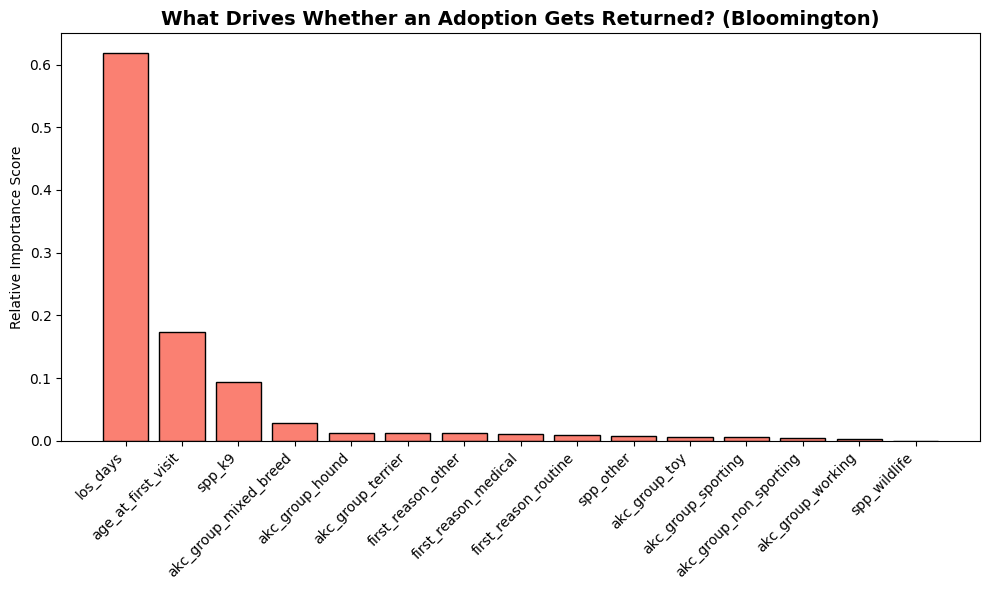

In [5]:
importances_bloomington = pd.Series(bloomington_model.feature_importances_, index=feature_order).sort_values(ascending=False)

print("=== Bloomington model feature importances ===")
print(importances_bloomington)
print()

plt.figure(figsize=(10, 6))
plt.title("What Drives Whether an Adoption Gets Returned? (Bloomington)", fontsize=14, fontweight='bold')
plt.bar(range(len(importances_bloomington)), importances_bloomington.values, color='salmon', edgecolor='black')
plt.xticks(range(len(importances_bloomington)), importances_bloomington.index, rotation=45, ha='right', fontsize=10)
plt.ylabel("Relative Importance Score")
plt.tight_layout()
plt.savefig('bloomington_feature_importances.png', dpi=300, bbox_inches='tight')
plt.show()